#  Cyclistic Bike Share Analysis
## Google Data Analytics Capstone Project

### About this project:
This is a case study analysis for Cyclistic, a fictional 
bike-share company in Chicago with 5,800+ bikes and 600 stations.

### The Business Question:
"How do annual members and casual riders use 
Cyclistic bikes differently?"

### Why this matters:
Cyclistic's finance team found that annual members are 
more profitable than casual riders. The marketing director
wants to convert casual riders into annual members —
but first we need to understand HOW they differ!

### My Approach:
Analyzed 12 months of real Cyclistic trip data 
(June 2025 - May 2026) = 5,681,098 clean rides!

Following the data analysis process:
- Ask -> defined the business question
- Prepare -> downloaded and organized 12 months of data
- Process -> cleaned and validated 5.8M rows of data
- Analyze -> found patterns across 5 different analyses
- Share -> created visualizations for each finding
- Act -> recommendations coming at the end!

### Tools used:
- Python (Pandas, Matplotlib) -> cleaning and analysis
- Tableau -> interactive dashboard
- GitHub -> portfolio presentation

### What I found (spoiler alert !!!):
- Members = commuters  | Casuals = leisure riders
  
Read on to see the evidence! LET"S GO!!!!!!!!!

### IMPORT LIBRARIES

In [1]:

import pandas as pd                                       # main tool for working with tables/data
import numpy as np                                        # helps with math calculations
import matplotlib.pyplot as plt                           # creates charts & graphs
import seaborn as sns                                     # makes charts pretty pretty
import os                                                # Python talking to computer's files/folders
import warnings                              
warnings.filterwarnings('ignore')                        # hides annoying yellow warning messages

print("All libraries loaded!!!")

All libraries loaded!!!


### LOAD FILES

In [2]:
# LOAD ALL 12 CSV FILES
folder_path = './'                                      # current folder (cyclistic_data)

all_dataframes = []                                  # empty list to store each file

for filename in sorted(os.listdir(folder_path)):       # look at each file one by one
    if filename.endswith('.csv'):                              # only pick CSV files
        filepath = os.path.join(folder_path, filename)           # full path to file
        df_temp = pd.read_csv(filepath)                              # read file as a table
        all_dataframes.append(df_temp)                            # add to our list
        print(f"Loaded: {filename} — {len(df_temp):,} rows")

# combine all 12 tables into ONE big table
df = pd.concat(all_dataframes, ignore_index=True)

print(f"\nTotal rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")

Loaded: 202506-divvy-tripdata.csv — 678,904 rows
Loaded: 202507-divvy-tripdata.csv — 763,432 rows
Loaded: 202508-divvy-tripdata.csv — 790,177 rows
Loaded: 202509-divvy-tripdata.csv — 714,759 rows
Loaded: 202510-divvy-tripdata.csv — 646,039 rows
Loaded: 202511-divvy-tripdata.csv — 356,628 rows
Loaded: 202512-divvy-tripdata.csv — 140,534 rows
Loaded: 202601-divvy-tripdata.csv — 137,787 rows
Loaded: 202602-divvy-tripdata.csv — 201,450 rows
Loaded: 202603-divvy-tripdata.csv — 317,037 rows
Loaded: 202604-divvy-tripdata.csv — 448,252 rows
Loaded: 202605-divvy-tripdata.csv — 653,704 rows
Loaded: summary_bike_type.csv — 4 rows
Loaded: summary_by_day.csv — 14 rows
Loaded: summary_by_hour.csv — 48 rows
Loaded: summary_by_month.csv — 24 rows
Loaded: summary_casual_hourly_index.csv — 24 rows
Loaded: summary_member_hourly_index.csv — 24 rows
Loaded: summary_ride_length.csv — 2 rows

Total rows: 5,848,843
Columns: ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_st

### OBSERVATIONS:
- Successfully loaded 12 months of data (June 2025 - May 2026)
- Total of 5,848,703 rows and 13 columns
- Summer months (July, August) had the most rides
- Winter months (December, January) had significantly fewer rides

### FIRST LOOK (Excited!!!)

In [3]:
# LET US LOOK AT DATA... LET'S GOOOOO
print("=== SIZE OF DATA (rows, columns) ===")
print(df.shape)

print("\n=== DATA TYPES OF EACH COLUMN ===")
print(df.dtypes)

print("\n=== FIRST 5 ROWS ===")
df.head()

=== SIZE OF DATA (rows, columns) ===
(5848843, 20)

=== DATA TYPES OF EACH COLUMN ===
ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
ride_count            float64
pct                   float64
day_of_week            object
hour                  float64
month                  object
index                 float64
median_mins           float64
dtype: object

=== FIRST 5 ROWS ===


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_count,pct,day_of_week,hour,month,index,median_mins
0,0E43949BF937C7DA,electric_bike,2025-06-05 21:24:56.104,2025-06-05 21:38:44.446,Clark St & Armitage Ave,CHI00474,Dearborn Pkwy & Delaware Pl,CHI00306,41.918306,-87.636282,41.898969,-87.629912,member,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1CDEA40FEAF21789,classic_bike,2025-06-14 13:03:34.478,2025-06-14 13:13:19.791,Dearborn Pkwy & Delaware Pl,CHI00306,Kingsbury St & Kinzie St,CHI00299,41.898969,-87.629912,41.889177,-87.638506,member,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7ECEB1638575575C,classic_bike,2025-06-09 13:30:22.540,2025-06-09 13:39:53.640,Dearborn Pkwy & Delaware Pl,CHI00306,Kingsbury St & Kinzie St,CHI00299,41.898969,-87.629912,41.889177,-87.638506,member,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F275084E25F5A131,electric_bike,2025-06-15 12:48:13.321,2025-06-15 13:00:18.798,Clark St & Elm St,CHI00281,NaN,NaN,41.902970,-87.631300,41.920000,-87.650000,member,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F42E81C85AC722FB,electric_bike,2025-06-19 07:54:26.103,2025-06-19 08:04:36.583,Damen Ave & Cortland St,CHI00388,NaN,NaN,41.915983,-87.677335,41.940000,-87.690000,member,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### OBSERVATIONS:
- Key column 'member_casual' identifies rider type
- 'started_at' and 'ended_at' are stored as text (object)-> need to convert to datetime
- Some rows have missing station names (NaN)-> especially for electric bikes
- GPS coordinates (lat/lng) are stored correctly as numbers

## Time to Clean the Data!!!

Let's get cleaningggg!!!!

Before we analyze anything we need to fix a few things:
- Convert dates from text to real datetime format
- Calculate how long each ride was
- Remove bad(or fake) rides (too short or too long)
- Drop any rows with missing imp info

Dirty data = wrong insights. Clean data = good insights!!!!

In [4]:
# CLEAN CLEAN CLEANNN!!!

# 1. Convert date columns from text to datetime format
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# 2. Calculate ride length in minutes
# ended_at minus started_at gives us the duration
df['ride_length_mins'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# 3. Extract useful time info from the date
df['day_of_week'] = df['started_at'].dt.day_name()    # Monday, Tuesday...
df['month'] = df['started_at'].dt.strftime('%b %Y')   # Jun 2025, Jul 2025...
df['hour'] = df['started_at'].dt.hour                 # 0, 1, 2... 23

# 4. Remove bad data
# rides under 1 min? how is that possible right? so... it has to be false starts, over 24 hours?? also likely errors(maybe someone forgot to return the bike)
df_clean = df[
    (df['ride_length_mins'] >= 1) &
    (df['ride_length_mins'] <= 1440)  # only keeping everything in between 1min-24hour -> real, valid rides
].copy()

# 5. Remove rows where member_casual is missing (critical column, I mean, cause the whole analysis is to learn about members' patterns)
df_clean = df_clean.dropna(subset=['member_casual'])

print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after cleaning:  {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,}")

Rows before cleaning: 5,848,843
Rows after cleaning:  5,681,508
Rows removed: 167,335


## Cleaning Results:

- Before it was 5,848,703 rows, removed 167,195 invalid rides. That is like.... (quick help) yah 2.8% of data. WoW
- Final clean dataset: 5,681,508 valid rides
- Invalid rides = rides under 1 minute or over 24 hours
- All dates converted to proper datetime format
- Added 3 new columns: ride_length_mins, day_of_week, month

## Quick Check on Clean Data:
#### Casue We Don't Trust Easily
##### LET'S GOOOOO!!!

In [5]:

# 1. Shape of clean data
print("=== CLEAN DATA SIZE ===")
print(df_clean.shape)

# 2. Column names (how many columns now?)
print("\n=== ALL COLUMNS NOW ===")
print(df_clean.columns.tolist())

# 3. Check nulls in clean data
print("\n=== MISSING VALUES IN CLEAN DATA ===")
print(df_clean.isnull().sum())

# 4. Check member_casual specifically — should be ZERO nulls
print("\n=== MEMBER_CASUAL NULL CHECK ===")
print(f"Null values in member_casual: {df_clean['member_casual'].isnull().sum()}")

# VERIFY DATE COLUMNS WERE CONVERTED CORRECTLY
print("=== DATA TYPES AFTER CLEANING ===")
print(df_clean.dtypes)

# 5. Unique values in member_casual
print("\n=== UNIQUE RIDER TYPES ===")
print(df_clean['member_casual'].value_counts())

=== CLEAN DATA SIZE ===
(5681508, 21)

=== ALL COLUMNS NOW ===
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual', 'ride_count', 'pct', 'day_of_week', 'hour', 'month', 'index', 'median_mins', 'ride_length_mins']

=== MISSING VALUES IN CLEAN DATA ===
ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1153045
start_station_id      1153045
end_station_name      1190321
end_station_id        1190321
start_lat                   0
start_lng                   0
end_lat                   253
end_lng                   253
member_casual               0
ride_count            5681508
pct                   5681508
day_of_week                 0
hour                        0
month                       0
index                 5681508
median_mins           5681508
ri

## Clean Data Verification (casue we don't trust easily)

### Size:
- Clean dataset: 5,681,508 rows and 17 columns
- Original had 13 columns, we added 4 new ones:
  ride_length_mins, day_of_week, month, hour

### Data Types:
- started_at: successfully converted from text -> datetime64 
- ended_at: successfully converted from text -> datetime64 
- ride_length_mins: float64 (decimal numbers, perfect for calculations)
- hour: int32  (whole numbers 0-23)

### Rider Types:
- Members: 3,668,166 rides 
- Casuals: 2,013,342 rides 
- Members have almost DOUBLE the rides of casuals!
- BUT we can't tell if that's because there are more members
  or because members ride more per person, data privacy
  means we don't have individual user IDs!
- member_casual has ZERO null values 

### Missing Values:
- start_station_name: 1,153,045 missing. OMGGGGGGG wait let be think.... oh wait it is normal! 
  electric bikes don't need fixed stations, they use GPS instead. WHEWWWWWW
- end_station_name: 1,190,321 missing -> same reason
- end_lat/end_lng: 253 missing ??? oh nooooo, truly bad rides!
  no station AND no GPS???? so no idea where ride ended ???
  will have to remove these in next step... 

### WELL OTHER THAN THAT WE DID CLEANED GOOOODDDDD

## Wait a minute..... Before We Delete Anything!

I had a question: what if only ONE type of rider has missing GPS?
- Won't that make our analysis biased towards the other type??
- And how much data can we even remove before it becomes a problem?

### The Bias Rule I learned: 
- Less than 1%  -> safe to remove 
- 1% - 5%       -> remove but mention it 
- More than 5%  -> investigate before removing 

So we check.... again....(hufff) BEFORE removing cause we don't trust easily!

In [6]:
# CHECK - which rider type has missing GPS?
# this tells us if removal will cause bias!

missing_gps = df_clean[df_clean['end_lat'].isnull()]
print("=== WHO HAS MISSING GPS? ===")
print(missing_gps['member_casual'].value_counts())
print("\n=== AS PERCENTAGE OF EACH GROUP ===")
print(missing_gps['member_casual'].value_counts() / 
      df_clean['member_casual'].value_counts() * 100)

# CHECK - which bike type has missing GPS?
print("=== WHICH BIKE TYPE HAS MISSING GPS? ===")
print(missing_gps['rideable_type'].value_counts())

print("\n=== AS PERCENTAGE OF EACH BIKE TYPE ===")
print(missing_gps['rideable_type'].value_counts() / 
      df_clean['rideable_type'].value_counts() * 100)

=== WHO HAS MISSING GPS? ===
member_casual
casual    166
member     87
Name: count, dtype: int64

=== AS PERCENTAGE OF EACH GROUP ===
member_casual
casual    0.008245
member    0.002372
Name: count, dtype: float64
=== WHICH BIKE TYPE HAS MISSING GPS? ===
rideable_type
classic_bike    253
Name: count, dtype: int64

=== AS PERCENTAGE OF EACH BIKE TYPE ===
rideable_type
classic_bike     0.013039
electric_bike         NaN
Name: count, dtype: float64


## WOWWWW, We have many interesting observations here:
### Which rider type has missing GPS?
- Casuals with missing GPS: 166 rides (quick help from....we know who...(Ahemmm)so..0.008% of all casuals)
- Members with missing GPS:  87 rides (0.002% of all members)

Both are TINY and roughly similar so removing won't bias 
our analysis towards either group!Yeahhh

### Which bike type has missing GPS?
- Classic bikes:  253 (wowwwww ALL of them?!)
- Electric bikes:   0 (none at all!)

WAIT... that's surprising!
cause I actually assumed electric bikes would have missing GPS 
since they roam freely without fixed stations...
BUT it's actually classic bikes!

OK.....Plot twist Nowww! Cause I just realised that classic bikes DON'T need GPS!
Classic bike  -> picked up FROM station, returned TO station
              -> station NAME already tells us the location!
Electric bike -> no fixed station so GPS is the ONLY way to track!

So missing GPS on classic bikes is likely a hardware/sync 
error at docking station. Not a rider behavior pattern! 

### But wait... do these 253 rides have station names at least??? Let's check


In [7]:
# I only checked first 10 rows before... let's check ALL 253!
print("=== END STATION INFO FOR ALL 253 MISSING GPS RIDES ===")
print(f"Total missing GPS rides: {len(missing_gps)}")

#Checking END and START STATION name
print("\n=== HOW MANY HAVE END STATION NAME? ===")
print(f"Has end station name: {missing_gps['end_station_name'].notna().sum()}")
print(f"Missing end station name: {missing_gps['end_station_name'].isna().sum()}")

print("\n=== HOW MANY HAVE START STATION NAME? ===")
print(f"Has start station name: {missing_gps['start_station_name'].notna().sum()}")
print(f"Missing start station name: {missing_gps['start_station_name'].isna().sum()}")

=== END STATION INFO FOR ALL 253 MISSING GPS RIDES ===
Total missing GPS rides: 253

=== HOW MANY HAVE END STATION NAME? ===
Has end station name: 0
Missing end station name: 253

=== HOW MANY HAVE START STATION NAME? ===
Has start station name: 253
Missing start station name: 0


### WELL Well well (Detective Mode ON) 
- Start station: 253/253 recorded  (we know where they started)
- End station:     0/253 recorded  (no idea where they ended)
- End GPS:         0/253 recorded  (no GPS either)

So every single ride started fine, but completely vanished at the end!
No end station AND no end GPS = absolutely NO idea where 
these rides ended! 

Could be :
- Stolen bikes 
- System crash during return  
- Damaged bikes removed from service 

### Now, as for data, do we even NEED to remove them? 🤔
For most of our analysis keeping them would actually be fine!
- Ride counts     -> doesn't need GPS 
- Ride length     -> doesn't need GPS 
- Day/Month       -> doesn't need GPS 
- Tableau maps    -> needs GPS 

BUT since it's only 253 rows ((Ahemmm) 0.000044% of data) removing 
them keeps everything perfectly clean with zero impact!
#### Decision: BANISHHHHHH! (Remove) 

In [8]:
# REMOVE 253 RIDES - confirmed ALL have no end info at all!
df_clean = df_clean.dropna(subset=['end_lat', 'end_lng'])

print(f"Final clean rows: {len(df_clean):,}")
print(f"Nulls remaining in end_lat: {df_clean['end_lat'].isnull().sum()}")
print(f"Nulls remaining in end_lng: {df_clean['end_lng'].isnull().sum()}")

Final clean rows: 5,681,255
Nulls remaining in end_lat: 0
Nulls remaining in end_lng: 0


###  FINAL CLEANING SUMMARY (PHEWWW) — WE'RE DONE CLEANING!!

- Original rows:        5,848,703
- Bad rides removed:      167,195  (rides under 1min or over 24hrs)
- Missing GPS removed:        253  (no end station AND no GPS)
                    
- Final clean rows:     5,681,255
- Total removed:          167,448
- Percentage removed:       2.86%   (well within safe limit!)
- Data kept:               97.14%  

### Final Rider Ratio:
- Members: 3,668,079 rides ((Ahemm) 64.56%)
- Casuals: 2,013,176 rides ((Ahemmm) 35.44%)

Virtually identical to before removal -> confirms our 
cleaning was completely fair and unbiased! 

### So far, we can see that:
- Members have almost DOUBLE the rides of casuals!
BUT we can't tell if that's because there are simply 
MORE members OR members ride more frequently per person
- Data privacy = no individual user IDs to find out...
Something to keep in mind during analysis! 👀

#### NOW WE'RE ACTUALLY READY FOR ANALYSIS!! YEAH!!


## Analysis Time!!!
We're going to answer the main question:
##### How do annual members and casual riders use Cyclistic bikes differently?

We'll look at:
1. Ride length differences
2. Rides by day of week
3. Rides by month/season
4. Rides by hour of day
5. Bike type preferences

##### LET'S GOOOOOOOO

### 1. Ride length differences

In [9]:
# ANALYSIS 1: RIDE LENGTH
# how long do members vs casuals ride?

ride_length = df_clean.groupby('member_casual')['ride_length_mins'].agg([
    'mean',   # average ride length
    'median', # middle value (less affected by extreme values)
    'max',    # longest ride
    'min'     # shortest ride
]).round(2)

print("=== RIDE LENGTH SUMMARY (minutes) ===")
print(ride_length)

=== RIDE LENGTH SUMMARY (minutes) ===
                mean  median      max  min
member_casual                             
casual         19.58   11.74  1439.98  1.0
member         12.31    8.77  1439.83  1.0


### 1. Ride Length Analysis !

- Casual average: 19.58 mins | median: 11.74 mins
- Member average: 12.31 mins | median: 8.77 mins
  
Using Mean: Casuals ride 59% longer than members on average!

BUT WAIT...  max value is 1439 minutes?? 
That's basically 24 hours on a bike?! 

This is exactly why we look at MEDIAN and not just MEAN! Extreme values (someone riding 
23.9 hours!) pull the mean up, 
##### so median is more honest!

- Casual median: 11.74 mins
- Member median: 8.77 mins

Using Median: casuals ride 34% longer!



##### What does this tell us about behavior? 🤔

Members ride SHORTER
- This SUGGESTS they might be using bikes for daily commute
- possibly point A to point B, quick and efficient?

Casuals ride LONGER
- This COULD indicate leisure/tourism riding
- maybe exploring the city with no rush?

We'll test this theory in the next analysis!

##### First clue about different usage patterns! 

### Chart 1: Ride Length Comparison

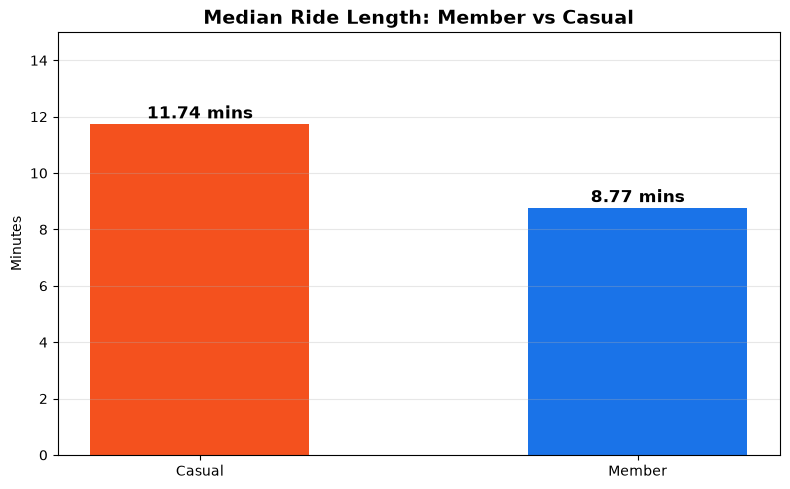

 Chart 1 saved!


In [10]:
# CHART 1: AVERAGE RIDE LENGTH (MEDIAN) - MEMBER VS CASUAL

fig, ax = plt.subplots(figsize=(8,5))

groups = ['Casual', 'Member']
medians = [11.74, 8.77]
colors = ['#f4511e', '#1a73e8']

bars = ax.bar(groups, medians, color=colors, width=0.5)

# add value labels on top of bars
for bar, val in zip(bars, medians):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.2, 
            f'{val} mins', 
            ha='center', fontweight='bold', fontsize=12)

ax.set_title('Median Ride Length: Member vs Casual', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Minutes')
ax.set_ylim(0, 15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart1_ride_length.png', dpi=150)
plt.show()
print(" Chart 1 saved!")

Note:  Using MEDIAN (not mean) to avoid extreme values like someone riding 24 hours pulling the average up!

Casuals ride 34% longer than members (median)
-> suggests leisure/exploratory riding 

Members take shorter, quicker rides
-> suggests point A to B commuting 

First clue about different usage patterns!

### 2. Rides by Day of Week
If our theory is correct:
- Members (commuters) -> should ride MORE on weekdays
- Casuals (leisure) -> should ride MORE on weekends
Let's find out!!!!

In [11]:
# ANALYSIS: RIDES BY DAY OF WEEK

# set correct day order (Monday to Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday', 'Sunday']

# count rides per day for each rider type
rides_by_day = df_clean.groupby(
    ['member_casual', 'day_of_week']
).size().reset_index(name='ride_count')

# sort days in correct order
rides_by_day['day_of_week'] = pd.Categorical(
    rides_by_day['day_of_week'], 
    categories=day_order, 
    ordered=True
)
rides_by_day = rides_by_day.sort_values('day_of_week')

print("=== RIDES BY DAY OF WEEK ===")
print(rides_by_day)

=== RIDES BY DAY OF WEEK ===
   member_casual day_of_week  ride_count
1         casual      Monday      235404
8         member      Monday      516214
5         casual     Tuesday      225650
12        member     Tuesday      580378
6         casual   Wednesday      227315
13        member   Wednesday      582467
4         casual    Thursday      256690
11        member    Thursday      588430
0         casual      Friday      309945
7         member      Friday      536909
2         casual    Saturday      413713
9         member    Saturday      458278
3         casual      Sunday      344459
10        member      Sunday      405403


In [12]:
# WEEKDAY vs WEEKEND COMPARISON

# separate weekdays and weekends
weekdays = ['Monday','Tuesday','Wednesday','Thursday','Friday']
weekends = ['Saturday','Sunday']

for rider in ['casual', 'member']:                           # loop through each rider type one by one (casual first, then member
    data = rides_by_day[rides_by_day['member_casual'] == rider]             # filter data to only show current rider type
    
    avg_weekday = data[data['day_of_week'].isin(weekdays)]['ride_count'].mean()
    avg_weekend = data[data['day_of_week'].isin(weekends)]['ride_count'].mean()
    change = ((avg_weekend - avg_weekday) / avg_weekday * 100).round(1)
    
    print(f"{rider.upper()}:")
    print(f"  Average weekday rides: {avg_weekday:,.0f}")
    print(f"  Average weekend rides: {avg_weekend:,.0f}")
    print(f"  Weekend change: {change}%")
    print()

CASUAL:
  Average weekday rides: 251,001
  Average weekend rides: 379,086
  Weekend change: 51.0%

MEMBER:
  Average weekday rides: 560,880
  Average weekend rides: 431,840
  Weekend change: -23.0%



### 2. Rides by Day of Week Analysis 

CASUAL riders:
- Weekday average: 251,001 rides
- Weekend average: 379,086 rides
##### 51% MORE rides on weekends!




MEMBER riders:
- Weekday average: 560,880 rides
- Weekend average: 431,840 rides  
##### 23% FEWER rides on weekends! 




This is strong evidence for our theory!!!
-  Casuals = leisure riders (spike on weekends)
-  Members = commuters (drop on weekends)

The opposite weekend patterns of these two groups
is the smoking gun! 
If members were leisure riders, they'd ALSO 
increase on weekends, but they don't!

##### Theory status: STRONGLY SUPPORTED! 

### Chart 2:  WEEKLY PATTERN - % OF EACH GROUP'S OWN WEEKLY RIDES

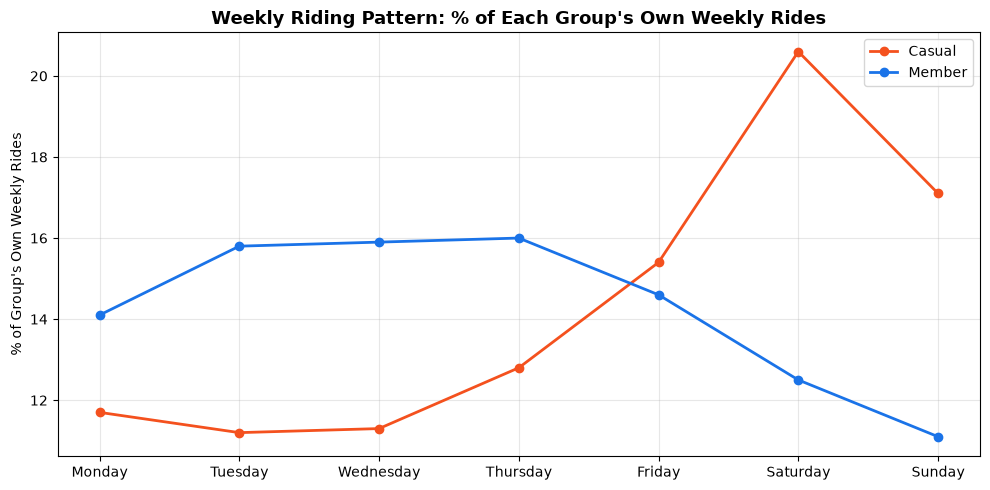

 Chart 2 saved!


In [13]:


day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# calculate % of each group's OWN weekly total
casual_total_week = rides_by_day[rides_by_day['member_casual']=='casual']['ride_count'].sum()
member_total_week = rides_by_day[rides_by_day['member_casual']=='member']['ride_count'].sum()

casual_days = rides_by_day[rides_by_day['member_casual']=='casual'].set_index('day_of_week').reindex(day_order)
member_days = rides_by_day[rides_by_day['member_casual']=='member'].set_index('day_of_week').reindex(day_order)

casual_pct = (casual_days['ride_count'] / casual_total_week * 100).round(1)
member_pct = (member_days['ride_count'] / member_total_week * 100).round(1)

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(day_order, casual_pct, marker='o', 
        label='Casual', color='#f4511e', linewidth=2)
ax.plot(day_order, member_pct, marker='o', 
        label='Member', color='#1a73e8', linewidth=2)

ax.set_title('Weekly Riding Pattern: % of Each Group\'s Own Weekly Rides', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('% of Group\'s Own Weekly Rides')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_day_of_week.png', dpi=150)
plt.show()
print(" Chart 2 saved!")

Note: Each line shows % of THAT GROUP'S OWN weekly rides


Each group's 7 days adds up to 100% of their own total
So height difference between lines = pure behavior! 

The CROSSING POINT on Friday is the key visual insight:
- Mon-Thu: Members dominate (higher % of their week)
- Fri-Sun: Casuals take over (higher % of their week)

Lines going in OPPOSITE directions on weekends
= members and casuals have fundamentally different
weekly riding patterns! 

###  3. Rides by Month
Let's see if season affects members and casuals differently.

Theory: 
- Casuals (leisure riders) might ride less in colder months

- Members (commuters) might stay more consistent


  since they need to get to work regardless of weather!

In [14]:
# ANALYSIS 3: RIDES BY MONTH

# count rides per month for each rider type
rides_by_month = df_clean.groupby(
    ['member_casual', 'month']
).size().reset_index(name='ride_count')

# our months aren't in calendar order by default, let's fix that
month_order = ['Jun 2025', 'Jul 2025', 'Aug 2025', 'Sep 2025', 
                'Oct 2025', 'Nov 2025', 'Dec 2025', 'Jan 2026',
                'Feb 2026', 'Mar 2026', 'Apr 2026', 'May 2026']

rides_by_month['month'] = pd.Categorical(
    rides_by_month['month'], 
    categories=month_order, 
    ordered=True
)
rides_by_month = rides_by_month.sort_values('month')

print("=== RIDES BY MONTH ===")
print(rides_by_month)

=== RIDES BY MONTH ===
   member_casual     month  ride_count
19        member  Jun 2025      379517
6         casual  Jun 2025      278675
18        member  Jul 2025      430392
5         casual  Jul 2025      308429
1         casual  Aug 2025      323523
14        member  Aug 2025      443125
12        casual  Sep 2025      254714
25        member  Sep 2025      440951
11        casual  Oct 2025      214373
24        member  Oct 2025      414088
10        casual  Nov 2025       94689
23        member  Nov 2025      251912
15        member  Dec 2025      109371
2         casual  Dec 2025       27087
4         casual  Jan 2026       23876
17        member  Jan 2026      109855
16        member  Feb 2026      157230
3         casual  Feb 2026       40072
20        member  Mar 2026      223643
7         casual  Mar 2026       84796
13        member  Apr 2026      308472
0         casual  Apr 2026      127014
9         casual  May 2026      235812
22        member  May 2026      399482
8 

###  Wait a minute... NaN months?? Needs investigation!!!!

When grouping by month, 157 rides showed up with NaN month!
But df_clean['month'] has ZERO nulls... so where did NaN come from??

Suspicious... let's dig deeper! 

In [15]:
# INVESTIGATE - why is month missing for some rows?
missing_month = df_clean[df_clean['month'].isnull()]

print(f"Total rows with missing month: {len(missing_month)}")
print("\n=== SAMPLE OF THESE ROWS ===")
print(missing_month[['started_at', 'ended_at', 'month', 'member_casual']].head(10))

Total rows with missing month: 0

=== SAMPLE OF THESE ROWS ===
Empty DataFrame
Columns: [started_at, ended_at, month, member_casual]
Index: []


###  Hmm... Zero nulls in df_clean['month']?

Wait so df_clean has ZERO null months...
but our rides_by_month table showed NaN rows!

That means the NaN didn't come from the RAW data —
it was created DURING our groupby/categorical step!

The culprit must be pd.Categorical() — when we convert
month to a categorical type with a fixed list of expected
months, ANY month not in our list automatically becomes NaN!

So there's a month in our data that we didn't expect...
Let's find out which one! 

In [16]:
# CHECK - are there months in our data NOT in our month_order list?
actual_months = df_clean['month'].unique()
print("=== MONTHS ACTUALLY IN OUR DATA ===")
print(sorted(actual_months))

print("\n=== MONTHS WE EXPECTED ===")
print(month_order)

# find any mismatch
missing_from_list = set(actual_months) - set(month_order)
print("\n=== MONTHS IN DATA BUT NOT IN OUR LIST (these became NaN!) ===")
print(missing_from_list)

=== MONTHS ACTUALLY IN OUR DATA ===
['Apr 2026', 'Aug 2025', 'Dec 2025', 'Feb 2026', 'Jan 2026', 'Jul 2025', 'Jun 2025', 'Mar 2026', 'May 2025', 'May 2026', 'Nov 2025', 'Oct 2025', 'Sep 2025']

=== MONTHS WE EXPECTED ===
['Jun 2025', 'Jul 2025', 'Aug 2025', 'Sep 2025', 'Oct 2025', 'Nov 2025', 'Dec 2025', 'Jan 2026', 'Feb 2026', 'Mar 2026', 'Apr 2026', 'May 2026']

=== MONTHS IN DATA BUT NOT IN OUR LIST (these became NaN!) ===
{'May 2025'}


### Found the Culprit! It was May 2025!!

Our data has 13 months, not 12!
May 2025 was hiding in our June 2025 file (oops)

Why? Divvy's monthly files aren't perfectly clean - 
some late May 2025 rides got included in the 
June 2025 file. Classic data messiness! (gezzs)

Since our declared scope is strictly:
June 2025 -> May 2026 (12 months)

May 2025 is outside our range -> needs to go!



But wait — before removing, let's check:
- How many rides? 
- Is it biased towards one rider type?
  



In [17]:
# check May 2025 rider split BEFORE removing
may2025 = df_clean[df_clean['month'] == 'May 2025']

print(f"Total May 2025 rides: {len(may2025)}")
print("\n=== RIDER TYPE SPLIT ===")
print(may2025['member_casual'].value_counts())

print("\n=== AS PERCENTAGE OF EACH GROUP ===")
print(round(may2025['member_casual'].value_counts() / 
      df_clean['member_casual'].value_counts() * 100, 3))

Total May 2025 rides: 157

=== RIDER TYPE SPLIT ===
member_casual
casual    116
member     41
Name: count, dtype: int64

=== AS PERCENTAGE OF EACH GROUP ===
member_casual
casual    0.006
member    0.001
Name: count, dtype: float64



- How many rides? (157 total)
- Is it biased towards one rider type?
  - Casual: 116 rides | Member: 41 rides

Both tiny percentages -> safe to remove! 

Decision: BANISH MAY 2025!!

In [18]:
# REMOVE 157 STRAY MAY 2025 RIDES - outside our declared 12-month scope (Jun 2025 - May 2026)
df_clean = df_clean[df_clean['month'] != 'May 2025']

print(f"Rows removed: 157")
print(f"New total: {len(df_clean):,}")
print(f"Months remaining: {sorted(df_clean['month'].unique())}")

Rows removed: 157
New total: 5,681,098
Months remaining: ['Apr 2026', 'Aug 2025', 'Dec 2025', 'Feb 2026', 'Jan 2026', 'Jul 2025', 'Jun 2025', 'Mar 2026', 'May 2026', 'Nov 2025', 'Oct 2025', 'Sep 2025']


###  Mystery of the Missing Month - Solved!

When we grouped rides by month, 157 rides showed up with month = NaN.
Investigated and found df_clean['month'] itself had 0 nulls...
so where did the NaN come from?

Turned out it was the pd.Categorical() step - any value not in our
month_order list automatically becomes NaN when converted!

Checked which month was sneaking in: 'May 2025'
- 116 casual + 41 member = 157 rides total
- Likely some late-May rides got logged in the June 2025 file
  (Divvy's monthly file cutoffs aren't always perfectly clean)

Since our project scope is strictly "last 12 months" 
(Jun 2025 - May 2026), May 2025 rides are outside that range.
Removed them to keep our 12-month claim accurate.

Removed: 157 rows (0.0028% of data) - negligible impact
New total: 5,681,098 rows
Confirmed: exactly 12 months remain 

Lesson learned: always double check categorical conversions
don't silently drop data into NaN!

In [19]:
# CHECK - were any of those 157 May 2025 rows spread across specific days?
# (we already removed them, so let's verify they wouldn't have changed our day-of-week % much)

# quick sanity check: 157 rows is what % of our smallest day-of-week group?
smallest_day_count = rides_by_day['ride_count'].min()
print(f"Smallest day-of-week group had: {smallest_day_count:,} rides")
print(f"157 stray rows = {157/smallest_day_count*100:.3f}% of even the smallest group")

Smallest day-of-week group had: 225,650 rides
157 stray rows = 0.070% of even the smallest group


###  Did removing 157 rows bias our earlier Day of Week analysis?

Our Day of Week analysis (Analysis 2) was run BEFORE we found
and removed the 157 stray May 2025 rows. Let's verify this 
didn't bias those results.

Checked: 157 rows as % of even our SMALLEST day-of-week group
(Tuesday casuals: 225,650 rides)
157 / 225,650 = 0.070%

Even in the worst case (all 157 landing on one day), this is
far too small to meaningfully shift any percentage we calculated.

Day of Week results remain valid

In [20]:
# RE-RUN MONTH ANALYSIS - now using the cleaned df_clean (May 2025 removed)
rides_by_month = df_clean.groupby(
    ['member_casual', 'month']
).size().reset_index(name='ride_count')

rides_by_month['month'] = pd.Categorical(
    rides_by_month['month'], 
    categories=month_order, 
    ordered=True
)
rides_by_month = rides_by_month.sort_values('month')

print("=== RIDES BY MONTH (CLEAN VERSION) ===")
print(rides_by_month)

=== RIDES BY MONTH (CLEAN VERSION) ===
   member_casual     month  ride_count
18        member  Jun 2025      379517
6         casual  Jun 2025      278675
17        member  Jul 2025      430392
5         casual  Jul 2025      308429
1         casual  Aug 2025      323523
13        member  Aug 2025      443125
11        casual  Sep 2025      254714
23        member  Sep 2025      440951
10        casual  Oct 2025      214373
22        member  Oct 2025      414088
9         casual  Nov 2025       94689
21        member  Nov 2025      251912
14        member  Dec 2025      109371
2         casual  Dec 2025       27087
4         casual  Jan 2026       23876
16        member  Jan 2026      109855
15        member  Feb 2026      157230
3         casual  Feb 2026       40072
19        member  Mar 2026      223643
7         casual  Mar 2026       84796
12        member  Apr 2026      308472
0         casual  Apr 2026      127014
8         casual  May 2026      235812
20        member  May 202

In [21]:
# AUGUST vs JANUARY COMPARISON - biggest seasonal swing

aug_casual = rides_by_month[(rides_by_month['month']=='Aug 2025') & (rides_by_month['member_casual']=='casual')]['ride_count'].values[0]
jan_casual = rides_by_month[(rides_by_month['month']=='Jan 2026') & (rides_by_month['member_casual']=='casual')]['ride_count'].values[0]

aug_member = rides_by_month[(rides_by_month['month']=='Aug 2025') & (rides_by_month['member_casual']=='member')]['ride_count'].values[0]
jan_member = rides_by_month[(rides_by_month['month']=='Jan 2026') & (rides_by_month['member_casual']=='member')]['ride_count'].values[0]

casual_drop = ((jan_casual - aug_casual) / aug_casual * 100).round(1)
member_drop = ((jan_member - aug_member) / aug_member * 100).round(1)

print("=== AUGUST (PEAK) vs JANUARY (LOWEST) ===")
print(f"Casual: {aug_casual:,} -> {jan_casual:,}  = {casual_drop}%")
print(f"Member: {aug_member:,} -> {jan_member:,}  = {member_drop}%")

=== AUGUST (PEAK) vs JANUARY (LOWEST) ===
Casual: 323,523 -> 23,876  = -92.6%
Member: 443,125 -> 109,855  = -75.2%


### 3. Rides by Month Analysis 

Both rider types follow Chicago's seasons - peak in summer, 
crash in winter. But the SIZE of the crash is very different!

August (peak) to January (lowest):
- Casuals: 323,523 → 23,876 = -92.6% drop!! 
- Members: 443,125 → 109,855 = -75.2% drop

Casuals almost COMPLETELY disappear in winter, while members
drop too but remain far more present.

This makes perfect sense with our commuter theory:
- Casuals (leisure) → no reason to bike in freezing weather 
- Members (commuters) → still need to get to work regardless! 

Theory status: WELL SUPPORTED!
Three analyses in a row now point the same direction! 

### Chart 3: MONTHLY PATTERN - % OF EACH GROUP'S OWN YEARLY RIDES

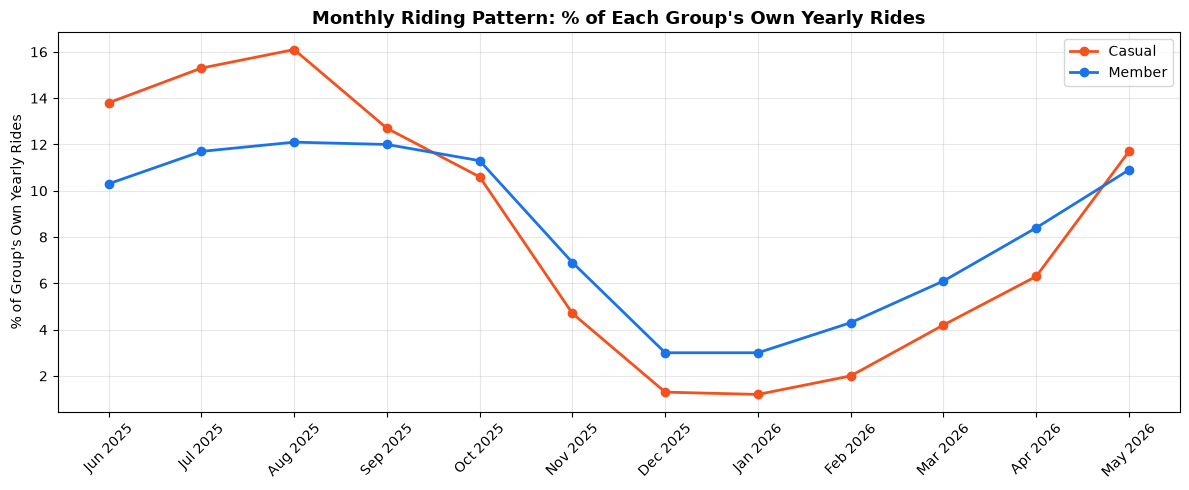

 Chart 3 saved!


In [22]:


month_order = ['Jun 2025', 'Jul 2025', 'Aug 2025', 'Sep 2025', 
               'Oct 2025', 'Nov 2025', 'Dec 2025', 'Jan 2026',
               'Feb 2026', 'Mar 2026', 'Apr 2026', 'May 2026']

# calculate % of each group's OWN yearly total
casual_total_year = rides_by_month[rides_by_month['member_casual']=='casual']['ride_count'].sum()
member_total_year = rides_by_month[rides_by_month['member_casual']=='member']['ride_count'].sum()

casual_months = rides_by_month[rides_by_month['member_casual']=='casual'].set_index('month').reindex(month_order)
member_months = rides_by_month[rides_by_month['member_casual']=='member'].set_index('month').reindex(month_order)

casual_pct = (casual_months['ride_count'] / casual_total_year * 100).round(1)
member_pct = (member_months['ride_count'] / member_total_year * 100).round(1)

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(month_order, casual_pct, marker='o', 
        label='Casual', color='#f4511e', linewidth=2)
ax.plot(month_order, member_pct, marker='o', 
        label='Member', color='#1a73e8', linewidth=2)

ax.set_title('Monthly Riding Pattern: % of Each Group\'s Own Yearly Rides', 
             fontsize=13, fontweight='bold')
ax.set_ylabel("% of Group's Own Yearly Rides")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart3_monthly.png', dpi=150)
plt.show()
print(" Chart 3 saved!")

Note: Each line = % of THAT GROUP'S OWN yearly rides
(each group's 12 months adds to 100%)  .....(cause we don't want any size bais)

Key things to notice:
- Summer (Jun-Aug): Casual line sits HIGHER
  -> casuals concentrate more of their year in summer!
- Winter (Dec-Jan): Casual line CRASHES way below members
  -> casual: only 1.3% of year in December!
  -> member: 3.0% of year in December (4x more than casuals!)
- Members stay more CONSISTENT year round
  -> commuters ride regardless of weather!
- Casuals follow the weather closely
  -> leisure riders stay home when it's cold!

December reality check:
- Casual December rides:  ~27,000  <- almost gone!
- Member December rides: ~110,000  <- still going strong!

### 4. Rides by Hour of Day
If members are commuters, we'd expect to see two spikes:
- Around 8 AM (going to work)
- Around 5 PM (going home)

Casuals should look more spread out - no fixed schedule!
Let's check! 

In [23]:
# ANALYSIS 4: RIDES BY HOUR OF DAY

rides_by_hour = df_clean.groupby(
    ['member_casual', 'hour']
).size().reset_index(name='ride_count')

# sort by hour properly (0 to 23)
rides_by_hour = rides_by_hour.sort_values(['member_casual', 'hour'])

print("=== RIDES BY HOUR OF DAY ===")
print(rides_by_hour.to_string())

=== RIDES BY HOUR OF DAY ===
   member_casual  hour  ride_count
0         casual   0.0       39234
1         casual   1.0       25195
2         casual   2.0       16691
3         casual   3.0        9309
4         casual   4.0        7422
5         casual   5.0       11830
6         casual   6.0       26805
7         casual   7.0       49650
8         casual   8.0       71407
9         casual   9.0       70525
10        casual  10.0       84944
11        casual  11.0      108220
12        casual  12.0      128335
13        casual  13.0      132761
14        casual  14.0      139963
15        casual  15.0      155426
16        casual  16.0      178494
17        casual  17.0      193381
18        casual  18.0      164985
19        casual  19.0      123864
20        casual  20.0       89661
21        casual  21.0       75775
22        casual  22.0       63940
23        casual  23.0       45243
24        member   0.0       32760
25        member   1.0       19968
26        member   2.0    

In [24]:
# COMPARE 8AM AND 5PM PEAKS WITH ACTUAL CODE - not just eyeballing the table

casual_8am = rides_by_hour[(rides_by_hour['hour']==8) & (rides_by_hour['member_casual']=='casual')]['ride_count'].values[0]
member_8am = rides_by_hour[(rides_by_hour['hour']==8) & (rides_by_hour['member_casual']=='member')]['ride_count'].values[0]

casual_5pm = rides_by_hour[(rides_by_hour['hour']==17) & (rides_by_hour['member_casual']=='casual')]['ride_count'].values[0]
member_5pm = rides_by_hour[(rides_by_hour['hour']==17) & (rides_by_hour['member_casual']=='member')]['ride_count'].values[0]

print("=== 8 AM COMPARISON ===")
print(f"Casual: {casual_8am:,}")
print(f"Member: {member_8am:,}")
print(f"Members ride {member_8am/casual_8am:.1f}x more than casuals at 8am")

print("\n=== 5 PM COMPARISON ===")
print(f"Casual: {casual_5pm:,}")
print(f"Member: {member_5pm:,}")
print(f"Members ride {member_5pm/casual_5pm:.1f}x more than casuals at 5pm")

# also check - what's the peak hour for EACH group separately?
casual_peak_hour = rides_by_hour[rides_by_hour['member_casual']=='casual'].sort_values('ride_count', ascending=False).iloc[0]
member_peak_hour = rides_by_hour[rides_by_hour['member_casual']=='member'].sort_values('ride_count', ascending=False).iloc[0]

print("\n=== PEAK HOUR FOR EACH GROUP ===")
print(f"Casual peak: hour {casual_peak_hour['hour']} with {casual_peak_hour['ride_count']:,} rides")
print(f"Member peak: hour {member_peak_hour['hour']} with {member_peak_hour['ride_count']:,} rides")

=== 8 AM COMPARISON ===
Casual: 71,407
Member: 267,752
Members ride 3.7x more than casuals at 8am

=== 5 PM COMPARISON ===
Casual: 193,381
Member: 396,935
Members ride 2.1x more than casuals at 5pm

=== PEAK HOUR FOR EACH GROUP ===
Casual peak: hour 17.0 with 193,381 rides
Member peak: hour 17.0 with 396,935 rides


In [25]:
casual_hourly = rides_by_hour[rides_by_hour['member_casual']=='casual'].sort_values('hour')
member_hourly = rides_by_hour[rides_by_hour['member_casual']=='member'].sort_values('hour')

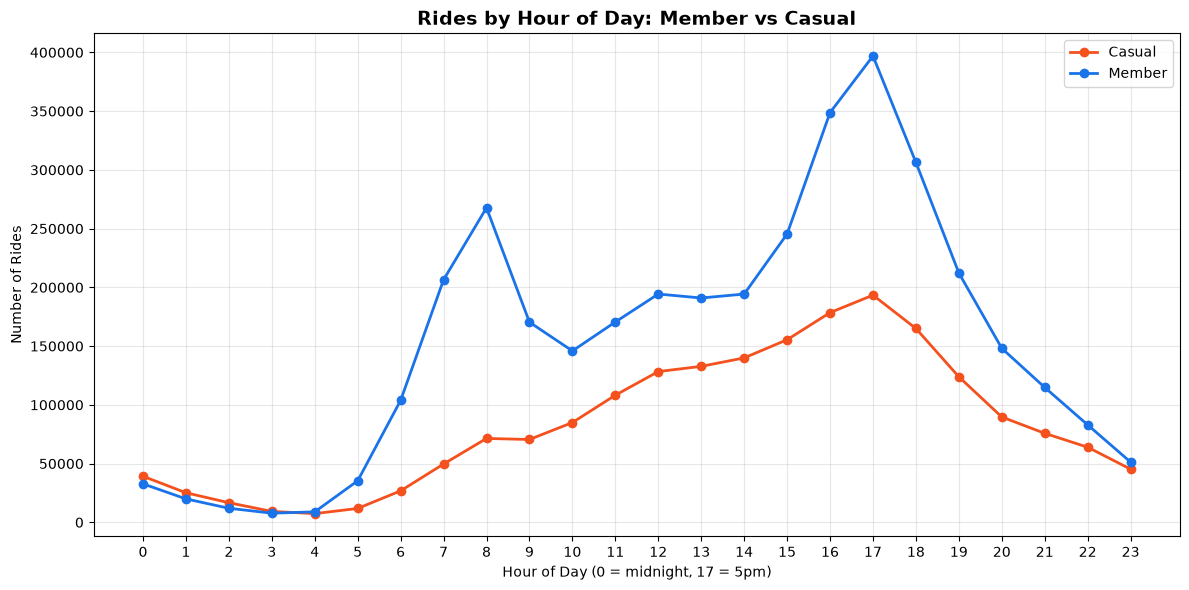

In [26]:
# VISUALIZE FULL 24-HOUR PATTERN - let the shape speak for itself

plt.figure(figsize=(12,6))

plt.plot(casual_hourly['hour'], casual_hourly['ride_count'], 
         marker='o', label='Casual', color='#f4511e', linewidth=2)
plt.plot(member_hourly['hour'], member_hourly['ride_count'], 
         marker='o', label='Member', color='#1a73e8', linewidth=2)

plt.title('Rides by Hour of Day: Member vs Casual', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0 = midnight, 17 = 5pm)')
plt.ylabel('Number of Rides')
plt.xticks(range(0,24))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hourly_pattern.png', dpi=150)
plt.show()

###  Wait a Minute... Is This Chart Fair?

There is a problem!!
Members have 3.6M total rides vs casuals 2M so members will ALWAYS look higher on a raw count chart even if their behavior was identical!

This is what we call BIAS (like you know how our fav cleb can "never be wrong", no maybe they were tricked by someone...lol)!!!! AHEMM back to our analysis it is actually called SIZE BAIS cause bigger group always looks  more active just because there are more of them, not necessarily because they behave differently!

So will be needing a fairer way to compare...

Solution: INDEX approach!!!!! 
Instead of raw counts, compare each hour to 
THAT GROUP'S OWN hourly average:
- 1.0 = exactly their normal hour
- 2.0 = twice their normal
- 0.5 = half their normal

This way group size becomes completely irrelevant!
Each group is judged against their OWN baseline 

In [27]:

# Index = how much does each hour deviate from THAT GROUP'S own average?
# 1.0 = exactly average, 2.0 = twice their normal, 0.5 = half their normal

# calculate each group's average rides per hour
casual_avg = casual_hourly['ride_count'].mean()
member_avg = member_hourly['ride_count'].mean()

print(f"Casual average rides per hour: {casual_avg:,.0f}")
print(f"Member average rides per hour: {member_avg:,.0f}")

# calculate index for each hour
casual_hourly = casual_hourly.copy()
member_hourly = member_hourly.copy()

casual_hourly['index'] = (casual_hourly['ride_count'] / casual_avg).round(2)
member_hourly['index'] = (member_hourly['ride_count'] / member_avg).round(2)

print("\n=== CASUAL HOURLY INDEX ===")
print(casual_hourly[['hour','ride_count','index']].to_string(index=False))

print("\n=== MEMBER HOURLY INDEX ===")
print(member_hourly[['hour','ride_count','index']].to_string(index=False))

Casual average rides per hour: 83,878
Member average rides per hour: 152,835

=== CASUAL HOURLY INDEX ===
 hour  ride_count  index
  0.0       39234   0.47
  1.0       25195   0.30
  2.0       16691   0.20
  3.0        9309   0.11
  4.0        7422   0.09
  5.0       11830   0.14
  6.0       26805   0.32
  7.0       49650   0.59
  8.0       71407   0.85
  9.0       70525   0.84
 10.0       84944   1.01
 11.0      108220   1.29
 12.0      128335   1.53
 13.0      132761   1.58
 14.0      139963   1.67
 15.0      155426   1.85
 16.0      178494   2.13
 17.0      193381   2.31
 18.0      164985   1.97
 19.0      123864   1.48
 20.0       89661   1.07
 21.0       75775   0.90
 22.0       63940   0.76
 23.0       45243   0.54

=== MEMBER HOURLY INDEX ===
 hour  ride_count  index
  0.0       32760   0.21
  1.0       19968   0.13
  2.0       11978   0.08
  3.0        7801   0.05
  4.0        8931   0.06
  5.0       35357   0.23
  6.0      103806   0.68
  7.0      206469   1.35
  8.0      2677

### 4. Rides by Hour Analysis 
To fairly compare two groups of very different sizes (members 3.6M vs casuals 2M rides), we used an INDEX:

Index = each hour's rides ÷ that group's own hourly average 1.0 = exactly their normal, 2.0 = twice their normal

Key findings:

8 AM (morning commute):

- Casual index: 0.85 -> BELOW their own average!
- Member index: 1.75 -> 75% ABOVE their own average!
  
5 PM (evening commute):

- Casual index: 2.31 -> their peak hour
- Member index: 2.60 -> their peak hour

Most telling difference:
At 8am members are 75% ABOVE their normal
while casuals are actually BELOW their normal!
That gap is the clearest commuter signal we found!

Theory status: WELL SUPPORTED across all 4 analyses! 



### Chart 4: Hourly Riding Index

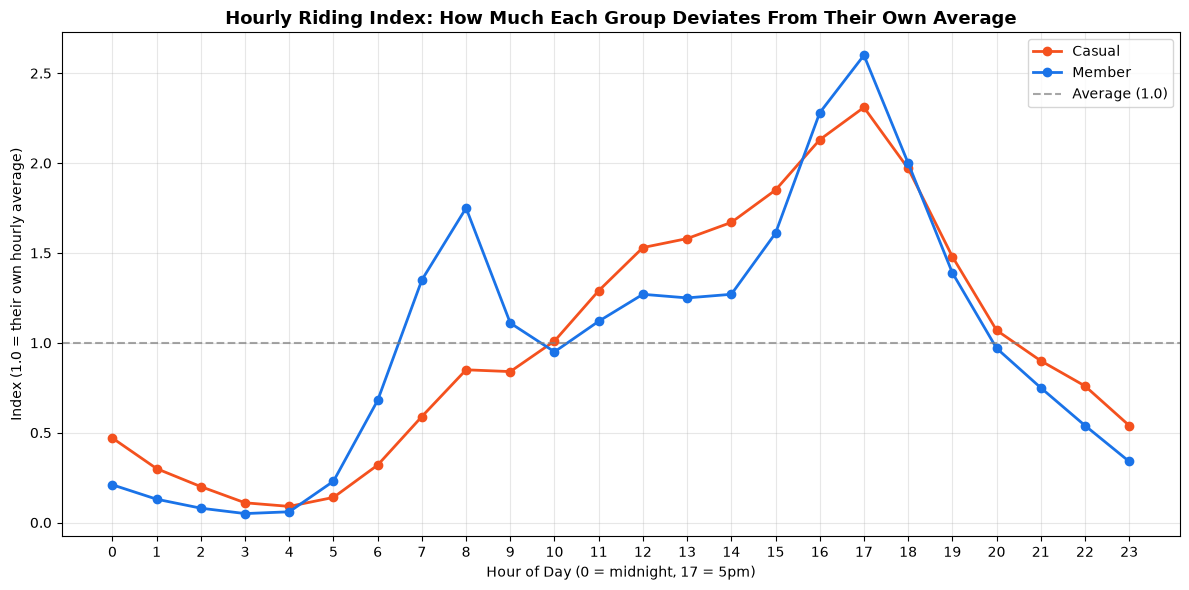

In [28]:
# INDEX CHART - fairest visualization

plt.figure(figsize=(12,6))

plt.plot(casual_hourly['hour'], casual_hourly['index'], 
         marker='o', label='Casual', color='#f4511e', linewidth=2)
plt.plot(member_hourly['hour'], member_hourly['index'], 
         marker='o', label='Member', color='#1a73e8', linewidth=2)

# add reference line at 1.0 (= average)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='Average (1.0)')

plt.title('Hourly Riding Index: How Much Each Group Deviates From Their Own Average', 
          fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day (0 = midnight, 17 = 5pm)')
plt.ylabel('Index (1.0 = their own hourly average)')
plt.xticks(range(0,24))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hourly_index.png', dpi=150)
plt.show()

Note: Index = each hour's rides ÷ that group's own hourly average
1.0 (dotted line) = exactly their normal hour
Above 1.0 = busier than normal, Below 1.0 = quieter than normal

Shape of the day:
- Members -> classic TWO humps 
  8am spike: index 1.75 (75% busier than their normal!)
  drops mid-morning to 0.95 (below their own average!)
  5pm spike: index 2.60 (their busiest hour!)
  = textbook commuter schedule! 

- Casuals -> ONE smooth hill 
  8am: only 0.85 (actually BELOW their own average!)
  gradually builds through afternoon
  5pm peak: index 2.31
  no morning spike = no fixed schedule! 

So, at 8am "members" are 75% ABOVE their normal
while "casuals" are actually BELOW their normal!




### 5. Bike Type Preferences
Do members and casuals prefer different types of bikes?

Available types: classic bike, electric bike

Let's check!

In [29]:
# ANALYSIS 5: BIKE TYPE PREFERENCES

bike_type = df_clean.groupby(
    ['member_casual', 'rideable_type']
).size().reset_index(name='ride_count')

# calculate percentage WITHIN each group
bike_type['pct'] = bike_type.groupby('member_casual')['ride_count'].transform(
    lambda x: (x / x.sum() * 100).round(1)
)

print("=== BIKE TYPE PREFERENCES ===")
print(bike_type)

=== BIKE TYPE PREFERENCES ===
  member_casual  rideable_type  ride_count   pct
0        casual   classic_bike      656977  32.6
1        casual  electric_bike     1356083  67.4
2        member   classic_bike     1283034  35.0
3        member  electric_bike     2385004  65.0


### 5. Bike Type Preferences Analysis 

CASUAL: Classic 32.6% | Electric 67.4%

MEMBER: Classic 35.0% | Electric 65.0%

Honestly? Both groups are very similar here!

Only 2.4% difference in electric bike preference.

Both groups strongly prefer electric bikes (~66-67%)


This analysis shows that bike TYPE preference
is NOT a meaningful differentiator between
members and casuals - both love electric bikes! 



### CHART 5: BIKE TYPE PREFERENCES - MEMBER VS CASUAL

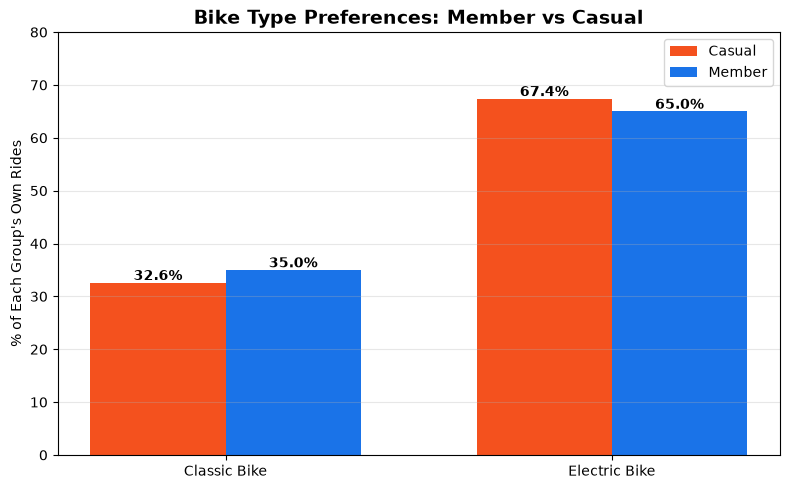

 Chart 5 saved!


In [30]:


fig, ax = plt.subplots(figsize=(8,5))

# data
bike_types = ['Classic Bike', 'Electric Bike']
casual_pcts = [32.6, 67.4]
member_pcts = [35.0, 65.0]

x = range(len(bike_types))
width = 0.35

# side by side bars
bars1 = ax.bar([i - width/2 for i in x], casual_pcts, 
               width, label='Casual', color='#f4511e')
bars2 = ax.bar([i + width/2 for i in x], member_pcts, 
               width, label='Member', color='#1a73e8')

# add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height()}%',
            ha='center', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height()}%',
            ha='center', fontweight='bold')

ax.set_title('Bike Type Preferences: Member vs Casual',
             fontsize=14, fontweight='bold')
ax.set_ylabel('% of Each Group\'s Own Rides')
ax.set_xticks(list(x))
ax.set_xticklabels(bike_types)
ax.legend()
ax.set_ylim(0, 80)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart5_bike_type.png', dpi=150)
plt.show()
print(" Chart 5 saved!")

Note: Both groups' % of their OWN rides by bike type
(size bias removed - each group adds to 100%)

Key finding: They're surprisingly similar!
- Both strongly prefer electric bikes (~66-67%)
- Only 2.4% difference between groups
- Bike type is NOT a meaningful differentiator!

Sometimes "they're similar here" IS the finding! 


##  Analysis Complete!!!! HURRAYYYY!!!
### Here's What We Found!

### Main Question:

"How do annual members and casual riders use Cyclistic bikes differently?"

### Answer:
#### They use bikes for completely different purposes:

Members = Transportation 
- Shorter rides (median 8.77 mins)
- Consistent weekday riding
- Clear 8am and 5pm commute spikes
- Stay active even in winter
- Behavior pattern = getting to work!

Casuals = Recreation 
- Longer rides (median 11.74 mins)
- Peak on weekends (+51% vs weekdays)
- No fixed schedule (gradual afternoon build)
- Almost disappear in winter (-92.6% drop!)
- Behavior pattern = leisure and fun!

### Where they're similar:
- Both strongly prefer electric bikes (~66-67%)
- Both peak at 5pm overall

### Evidence strength:
All 4 key analyses pointed the same direction:
- ride length ✅ day of week ✅ monthly ✅ hourly ✅
= WELL SUPPORTED Conclusion!

### So what does this mean for Cyclistic? 
To convert casuals into members, Cyclistic needs to
answer one key question FOR casuals:
- "Why would I pay for annual membership when I only ride on weekends in summer for fun?"

That's the marketing challenge and our 3 recommendations will address exactly this! (coming up in the next section!)

##  Top 3 Recommendations

Based on our analysis, here's how Cyclistic can 
convert casual riders into annual members:

### Recommendation 1: Target Casuals at Their Peak Times
Casual riders are most active:
- Weekends (51% more than weekdays)
- Summer months (Jun-Aug)
- Afternoon hours (3-6pm)

-> Run membership conversion campaigns EXACTLY at these 
times and places! Pop-up promotions at popular stations
on Saturday afternoons in summer = maximum exposure!

### Recommendation 2: Create a Weekend/Summer Membership
Current problem: casuals only ride weekends in summer
Annual membership feels like poor value to them!

-> Introduce flexible membership options:
- Weekend-only membership (cheaper than annual)
- Seasonal summer pass
- "Try membership" trial periods in peak summer months

Give casuals a membership that fits THEIR riding style
and they're much more likely to convert!

### Recommendation 3: Show Casuals the Value of Year-Round Riding
Casuals almost disappear in winter (-92.6% drop!)
They don't see value in annual membership for winter

-> Marketing campaign showing:
- Safe winter cycling routes in Chicago
- Weather-appropriate gear tips
- Cost savings of membership vs paying per ride
- "Your bike is always ready" messaging

Convert their mindset from "summer activity" 
to "year-round transport option"!


These recommendations target casuals WHERE THEY ARE
(weekends, summer, afternoon) and address WHY they 
wouldn't buy annual membership (only ride seasonally)


### Final Note:

##### "Not everything that can be counted counts, and not everything that counts can be counted" - Albert Einstein 

And just like that our analysis has limitations too! 

We counted a LOT (5.6 million rides!!!) but some things
we simply couldn't count...

Our data doesn't distinguish between:
- Tourist casual riders (visiting Chicago temporarily)
- Local casual riders (Chicago residents riding for leisure)

This matters because:
- Tourists = will never buy annual membership
- Locals = our actual conversion targets!

A more targeted analysis would filter for 
repeat casual riders (same routes, similar times)
as these are likely locals, not tourists!

This would make our conversion recommendations 
much more precise!

##### This limitation actually opens up an exciting  future project:

"Can we identify LOCAL casual riders vs TOURISTS
using riding patterns alone?"

Potential approach:
- Filter casuals who ride repeatedly (same routes/times)
- These repeat riders = likely locals = better targets!
- One-time riders = likely tourists = different strategy!

That would be a whole separate analysis -
but would make conversion campaigns WAY more precise! 

For now though, our analysis answers the main question:
"How do members and casuals use Cyclistic differently?"

And the answer is CLEAR:
- Members = commuters 
- Casuals = leisure/recreation 

The recommendations target LOCAL casuals specifically
with the goal of showing them the year-round value
of an annual membership!

AND WITH THAT THE NOTEBOOK IS COMPLETE!!!!!!

5.6 million rows of data, 5 analyses, 5 charts,
3 recommendations and a whole lot of questioning
everything along the way (phewwww)

Next stop: Tableau Dashboard!!!!!!!

## EXPORT SUMMARY FILES FOR TABLEAU

In [31]:
# these files will be used to build our dashboard!

rides_by_day.to_csv('summary_by_day.csv', index=False)
rides_by_month.to_csv('summary_by_month.csv', index=False)
rides_by_hour.to_csv('summary_by_hour.csv', index=False)
bike_type.to_csv('summary_bike_type.csv', index=False)

# export hourly index too
casual_hourly.to_csv('summary_casual_hourly_index.csv', index=False)
member_hourly.to_csv('summary_member_hourly_index.csv', index=False)

print("All summary files exported!")
print("Check your cyclistic_data folder for these files:")
print("- summary_by_day.csv")
print("- summary_by_month.csv")
print("- summary_by_hour.csv")
print("- summary_bike_type.csv")
print("- summary_casual_hourly_index.csv")
print("- summary_member_hourly_index.csv")

All summary files exported!
Check your cyclistic_data folder for these files:
- summary_by_day.csv
- summary_by_month.csv
- summary_by_hour.csv
- summary_bike_type.csv
- summary_casual_hourly_index.csv
- summary_member_hourly_index.csv


In [32]:
# CREATE RIDE LENGTH SUMMARY
ride_length_summary = pd.DataFrame({
    'member_casual': ['casual', 'member'],
    'median_mins': [11.74, 8.77]
})
ride_length_summary.to_csv('summary_ride_length.csv', index=False)
print("Done!")

Done!
